In [ ]:
%pip install open3d

  Using cached open3d-0.19.0-cp312-cp312-manylinux_2_31_x86_64.whl.metadata (4.3 kB)
  Using cached dash-4.0.0-py3-none-any.whl.metadata (11 kB)
  Using cached werkzeug-3.1.6-py3-none-any.whl.metadata (4.0 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached addict-2.4.0-py3-none-any.whl.metadata (1.0 kB)
  Using cached pillow-12.1.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (8.8 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached pandas-3.0.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x

In [1]:
import open3d as o3d
import numpy as np

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
file_path = "data/camera_view/Area_1_conferenceRoom_1_sample0_simCtr_0.ply"
pcd = o3d.io.read_point_cloud(file_path)

In [3]:
pcd_down = pcd.voxel_down_sample(voxel_size = 0.05)
print(f"Original points: {len(pcd.points)}")
print(f"Downsampled points: {len(pcd_down.points)}")

Original points: 60241
Downsampled points: 1902


In [4]:
o3d.visualization.draw_geometries([pcd_down],
                                  window_name = "S3DIS Visualization - Color by Label",
                                  width = 1280, 
                                  height = 720)

In [5]:
colors = np.asarray(pcd_down.colors)

unique_colors = np.unique(colors, axis = 0)
print(f"Found {len(unique_colors)} unique classes in this room.")

Found 147 unique classes in this room.


In [6]:
import matplotlib.pyplot as plt

In [7]:
rounded_colors = np.round(np.asarray(pcd_down.colors), decimals=2)
unique_colors, counts = np.unique(rounded_colors, axis = 0, return_counts = True)

print(f"Cleaned unique classes: {len(unique_colors)}")

Cleaned unique classes: 35


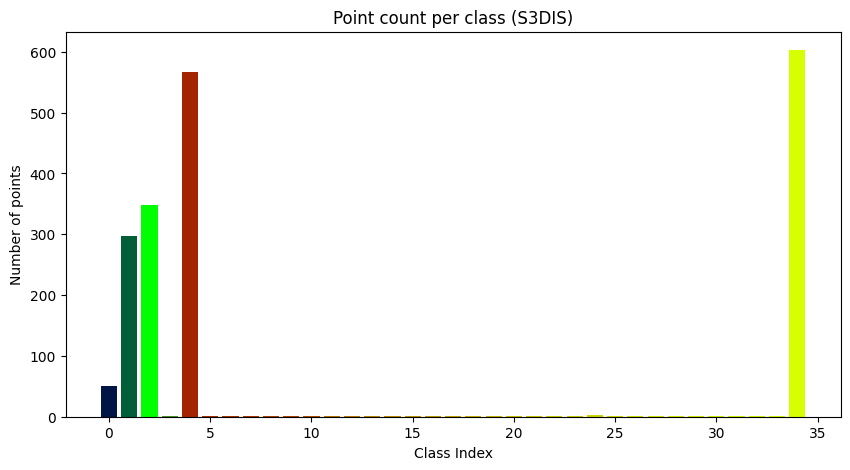

In [8]:
# Visualize the distribution of these classes
plt.figure(figsize = (10, 5))
plt.bar(range(len(counts)), counts, color = unique_colors)
plt.xlabel("Class Index")
plt.ylabel("Number of points")
plt.title("Point count per class (S3DIS)")
plt.show()

In [9]:
s3dis_labels = {
    0: 'ceiling', 1: 'floor', 2: 'wall', 3: 'beam', 4: 'column', 
    5: 'window', 6: 'door', 7: 'table', 8: 'chair', 9: 'sofa', 
    10: 'bookcase', 11: 'board', 12: 'clutter'
}

In [10]:
sorted_indices = np.argsort(-counts)
top_classes = unique_colors[sorted_indices[:13]]

print("Mapping top colors to potential elements: ")
for i, color in enumerate(top_classes):
    print(f"Index {i}: Color {color} - Points: {counts[sorted_indices[i]]}")

Mapping top colors to potential elements: 
Index 0: Color [0.84 1.   0.  ] - Points: 603
Index 1: Color [0.64 0.14 0.  ] - Points: 567
Index 2: Color [0. 1. 0.] - Points: 348
Index 3: Color [0.   0.37 0.22] - Points: 298
Index 4: Color [0.   0.08 0.27] - Points: 50
Index 5: Color [0.8  0.84 0.  ] - Points: 3
Index 6: Color [0.79 0.81 0.  ] - Points: 2
Index 7: Color [0.74 0.57 0.  ] - Points: 2
Index 8: Color [0.81 0.88 0.  ] - Points: 2
Index 9: Color [0.8  0.86 0.  ] - Points: 2
Index 10: Color [0.68 0.31 0.  ] - Points: 1
Index 11: Color [0.67 0.25 0.  ] - Points: 1
Index 12: Color [0.66 0.21 0.  ] - Points: 1


In [12]:
%pip install torch

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.2.0-py3-none-any.whl.metadata (10 kB)
  Using cached triton-3.6.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 6.7 MB/s  0:01:19m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 6.4 MB/s  0:01:00m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 6.7 MB/s  0:00:25m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 5.5 MB/s  0:00:35m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 6.5 MB/s  0:00:09m0:00:0100:01
Using cached triton-3.6.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (188.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 6.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━

In [40]:
import torch

top_5_indices = sorted_indices[:5]
top_5_colors = unique_colors[top_5_indices]

mask = np.any([np.all(rounded_colors == color, axis=1) for color in top_5_colors], axis=0)

points_filtered = np.asarray(pcd_down.points)[mask]
colors_filtered = rounded_colors[mask]

color_to_id = {tuple(color): i for i, color in enumerate(top_5_colors)}
labels_filtered = np.array([color_to_id[tuple(c)] for c in colors_filtered])

X_filtered = torch.tensor(points_filtered, dtype=torch.float32)
Y_filtered = torch.tensor(labels_filtered, dtype=torch.long)

X_Centered = X_filtered - X_filtered.mean(dim=0)
dist = torch.max(torch.sqrt(torch.sum(X_Centered**2, dim=1)))
X_normalized = X_Centered / dist

inputs = X_normalized.transpose(0, 1).unsqueeze(0)
targets = Y_filtered.unsqueeze(0)

print(f"Noise Removed! Kept {len(X_filtered)} points out of the original set.")
print(f"Final Input Shape: {inputs.shape}")

Noise Removed! Kept 1866 points out of the original set.
Final Input Shape: torch.Size([1, 3, 1866])


In [41]:
import torch.nn as nn 
import torch.nn.functional as F 

class PointNetSegmentation(nn.Module):
    def __init__(self, num_classes):
        super(PointNetSegmentation, self).__init__()

        self.conv1 = nn.Conv1d(3, 64, 1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, 1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 512, 1)
        self.bn3 = nn.BatchNorm1d(512)

        self.fc1 = nn.Conv1d(512 + 64, 256, 1)
        self.bn4 = nn.BatchNorm1d(256)
        self.fc2 = nn.Conv1d(256, 128, 1)
        self.bn5 = nn.BatchNorm1d(128)
        self.fc3 = nn.Conv1d(128, num_classes, 1)

    def forward(self, x):
        num_points = x.size(2)

        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        global_feat = self.bn3(self.conv3(x2))

        global_feat = torch.max(global_feat, 2, keepdim=True)[0]

        global_feat_repeated = global_feat.repeat(1, 1, num_points)
        combined = torch.cat([x1, global_feat_repeated], 1)

        x = F.relu(self.bn4(self.fc1(combined)))
        x = F.relu(self.bn5(self.fc2(x)))
        x = self.fc3(x)
        return x 

model = PointNetSegmentation(num_classes=5)
print("Segmentation Brain Initialized.")

Segmentation Brain Initialized.


In [ ]:
import torch.optim as optim

counts_tensor = torch.tensor(counts[sorted_indices[:5]], dtype=torch.float32)

soft_weights = torch.log(counts_tensor.sum() / counts_tensor)
soft_weights = soft_weights / soft_weights.sum() * 5.0 

print(f"Applying Balanced Weights: {soft_weights.tolist()}")

model = PointNetSegmentation(num_classes=5)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss(weight=soft_weights)

inputs = X_normalized.transpose(0, 1).unsqueeze(0)
targets = Y_filtered.unsqueeze(0)

print("Starting Training Loop...")

for epoch in range(2001):
    model.train()
    optimizer.zero_grad()
    outputs = model(inputs)
    loss = criterion(outputs.view(-1, 5), targets.view(-1))
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        _, predicted = torch.max(outputs, 1)
        unique_preds = torch.unique(predicted)
        acc = (predicted == targets).sum().item() / targets.size(1)
        print(f"Epoch {epoch}: Loss = {loss.item():.4f}, Accuracy = {acc:.2%}, Colors Found: {len(unique_preds)}/5")

print("Training Complete!")

Applying Structural Weights: [0.2796461284160614, 0.29740142822265625, 0.48455923795700073, 0.5658611059188843, 3.3725321292877197]
Starting Training Loop...
Epoch 0: Loss = 1.6484, Accuracy = 26.15%, Colors Found: 5/5
Epoch 100: Loss = 1.3039, Accuracy = 27.12%, Colors Found: 5/5
Epoch 200: Loss = 1.2074, Accuracy = 19.77%, Colors Found: 5/5
Epoch 300: Loss = 1.1380, Accuracy = 25.83%, Colors Found: 5/5
Epoch 400: Loss = 1.0624, Accuracy = 21.33%, Colors Found: 4/5
Epoch 500: Loss = 1.0694, Accuracy = 27.87%, Colors Found: 5/5
Epoch 600: Loss = 1.0186, Accuracy = 16.24%, Colors Found: 5/5
Epoch 700: Loss = 0.9540, Accuracy = 18.81%, Colors Found: 4/5
Epoch 800: Loss = 0.9473, Accuracy = 25.56%, Colors Found: 4/5
Epoch 900: Loss = 0.9368, Accuracy = 21.65%, Colors Found: 4/5
Epoch 1000: Loss = 0.9269, Accuracy = 18.38%, Colors Found: 4/5
Epoch 1100: Loss = 0.8999, Accuracy = 21.76%, Colors Found: 4/5
Epoch 1200: Loss = 0.8309, Accuracy = 25.40%, Colors Found: 4/5
Epoch 1300: Loss = 0.8

In [43]:
model.eval()
with torch.no_grad():
    outputs = model(inputs)
    _, predicted_ids = torch.max(outputs, 1)
    predicted_ids = predicted_ids.squeeze().cpu().numpy()

debug_colors = np.array([
    [1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 1, 0], [1, 0, 1]
])

print(f"Predictions generated for {len(predicted_ids)} points.")

for i in range(5):
    class_mask = (predicted_ids == i)
    class_points = points_filtered[class_mask] # Use your original real-world coordinates
    
    if len(class_points) > 0:
        print(f"Viewing Class {i}: {len(class_points)} points found.")
        temp_pcd = o3d.geometry.PointCloud()
        temp_pcd.points = o3d.utility.Vector3dVector(class_points)
        
        temp_pcd.paint_uniform_color(debug_colors[i])
        
        o3d.visualization.draw_geometries([temp_pcd], 
                                          window_name=f"AI Extraction: Class {i}",
                                          width=800, height=600)
    else:
        print(f"Class {i} was not predicted for any points.")

Predictions generated for 1866 points.
Class 0 was not predicted for any points.
Class 1 was not predicted for any points.
Class 2 was not predicted for any points.
Class 3 was not predicted for any points.
Viewing Class 4: 1866 points found.
